# Section 3: From Tokens to Vectors — Embeddings

After tokenization, each character is an integer ID like `9` or `4`. But the model still can't compute with those — the integer 9 is not "9× more important" than 1. The IDs are arbitrary labels with no numerical meaning.

**Embeddings** fix this by replacing each integer ID with a learned **vector** of real numbers. Instead of "token 9", the model sees a point in an 8-dimensional space. Two vectors that point in similar directions represent tokens the model has learned to treat as similar. This geometric structure is what allows the model to reason about relationships between tokens.

The key data structure is the **embedding matrix**: a table of shape `(vocab_size, d_model)` where row `i` is the vector for token `i`. Looking up an embedding is just selecting a row from this table.

## Setup: imports and the tokenizer

We reuse `CharTokenizer` from Section 2 to go from text → integer IDs, then hand those IDs to the embedding lookup.

In [1]:
import numpy as np
from tokenizer import CharTokenizer

# d_model is the dimensionality of every token vector throughout the model.
# It stays fixed from input to output — every sublayer takes (T, d_model) and
# returns (T, d_model). The original paper used 512; we use 8 so full vectors
# fit on screen and we can inspect every number.
D_MODEL = 8

# Fix the random seed so embedding values are identical across runs.
# Without this, every restart produces different numbers, making debugging impossible.
rng = np.random.default_rng(seed=42)

sentence = "the cat sat on the mat"
tok = CharTokenizer(sentence)
ids = tok.encode(sentence)

print(f"Sentence      : {sentence!r}")
print(f"Token IDs     : {ids}")
print(f"Vocab size    : {tok.vocab_size}  (one embedding row per unique character)")
print(f"d_model       : {D_MODEL}  (each token will become a vector of this length)")

Sentence      : 'the cat sat on the mat'
Token IDs     : [9, 4, 3, 0, 2, 1, 9, 0, 8, 1, 9, 0, 7, 6, 0, 9, 4, 3, 0, 5, 1, 9]
Vocab size    : 10  (one embedding row per unique character)
d_model       : 8  (each token will become a vector of this length)


## Step 1: Build the embedding matrix

The embedding matrix is a `(vocab_size, d_model)` table of random numbers — one row per token. During training, gradient descent adjusts these numbers so semantically similar tokens end up with geometrically similar rows. For now we initialise randomly; the mechanics are the same either way.

**Why scale by `1/√d_model`?** Each entry is drawn from a normal distribution. The *norm* (length) of a vector grows with its dimension — a `d_model=512` vector would be much longer than a `d_model=8` one if we used the same scale. Dividing by `√d_model` keeps the typical vector length roughly constant regardless of dimension, which prevents downstream dot products from exploding.

In [2]:
def make_embedding_matrix(vocab_size: int, d_model: int) -> np.ndarray:
    # Scale controls the spread of the initial random values.
    # 1/sqrt(d_model) keeps vector norms ~ O(1) regardless of how large d_model is.
    scale = 1.0 / np.sqrt(d_model)

    # Each row is a random vector representing one vocabulary token.
    # Shape: (vocab_size, d_model) — one row per unique token.
    return rng.normal(loc=0.0, scale=scale, size=(vocab_size, d_model))


E = make_embedding_matrix(tok.vocab_size, D_MODEL)

print(f"Embedding matrix shape: {E.shape}  → (vocab_size={tok.vocab_size}, d_model={D_MODEL})")
print()
print("Full embedding matrix (each row = one character's vector):")
print("     ", "  ".join(f"dim{i}" for i in range(D_MODEL)))
for ch, row in zip(sorted(tok.stoi.keys()), E):
    print(f"  {ch!r:3s}", "  ".join(f"{v:+.3f}" for v in row))

Embedding matrix shape: (10, 8)  → (vocab_size=10, d_model=8)

Full embedding matrix (each row = one character's vector):
      dim0  dim1  dim2  dim3  dim4  dim5  dim6  dim7
  ' ' +0.108  -0.368  +0.265  +0.333  -0.690  -0.460  +0.045  -0.112
  'a' -0.006  -0.302  +0.311  +0.275  +0.023  +0.399  +0.165  -0.304
  'c' +0.130  -0.339  +0.311  -0.018  -0.065  -0.241  +0.432  -0.055
  'e' -0.151  -0.124  +0.188  +0.129  +0.146  +0.152  +0.757  -0.144
  'h' -0.181  -0.288  +0.218  +0.399  -0.040  -0.297  -0.291  +0.230
  'm' +0.263  +0.192  -0.235  +0.082  +0.041  +0.077  +0.308  +0.079
  'n' +0.240  +0.024  +0.102  +0.223  -0.515  -0.113  -0.166  -0.226
  'o' -0.097  +0.529  -0.306  +0.342  -0.595  -0.118  +0.058  +0.207
  's' +0.251  +0.280  -0.123  -0.163  +0.303  -0.068  -0.451  -0.401
  't' -0.325  +0.176  +0.050  +0.244  -0.151  +0.056  +0.221  -0.109


## Step 2: Look up embeddings for a sequence

Given a list of token IDs, we select the corresponding rows from the embedding matrix. The result is a `(seq_len, d_model)` matrix — one vector per token, in order.

In NumPy, `E[ids]` performs **fancy indexing**: it selects rows by index. This is the entire "embedding lookup" operation. In PyTorch it is `nn.Embedding(vocab_size, d_model)(token_ids)` — same idea, with gradients.

In [3]:
def embed(token_ids: list[int], embedding_matrix: np.ndarray) -> np.ndarray:
    # Fancy indexing: selects rows from the matrix at the given positions, in order.
    # This is O(seq_len) — one row lookup per token, no loops needed.
    return embedding_matrix[token_ids]


X = embed(ids, E)

print(f"Token IDs shape : {len(ids)} integers")
print(f"Embedding output: {X.shape}  → (seq_len={len(ids)}, d_model={D_MODEL})")
print()
print("First 5 rows of X (first 5 characters of the sentence):")
for i in range(5):
    ch = sentence[i]
    print(f"  pos {i} ({ch!r}): {X[i].round(3)}")

Token IDs shape : 22 integers
Embedding output: (22, 8)  → (seq_len=22, d_model=8)

First 5 rows of X (first 5 characters of the sentence):
  pos 0 ('t'): [-0.325  0.176  0.05   0.244 -0.151  0.056  0.221 -0.109]
  pos 1 ('h'): [-0.181 -0.288  0.218  0.399 -0.04  -0.297 -0.291  0.23 ]
  pos 2 ('e'): [-0.151 -0.124  0.188  0.129  0.146  0.152  0.757 -0.144]
  pos 3 (' '): [ 0.108 -0.368  0.265  0.333 -0.69  -0.46   0.045 -0.112]
  pos 4 ('c'): [ 0.13  -0.339  0.311 -0.018 -0.065 -0.241  0.432 -0.055]


## Step 3: Verify that repeated characters share their vector

Because the embedding matrix has one row *per token type* (not per position), every occurrence of `'t'` in the sentence maps to exactly the same vector. This is by design — the position encoding added in a later section is what tells the model *where* a token appears; the embedding only tells it *what* it is.

In [4]:
# Find every position where 't' appears in the sentence.
t_positions = [i for i, ch in enumerate(sentence) if ch == 't']
print(f"'t' appears at positions: {t_positions}")
print(f"  (characters: {[sentence[i] for i in t_positions]})")
print()

# All those positions must map to the same embedding row.
print("Embedding vector for 't' at each position (should all be identical):")
for pos in t_positions:
    print(f"  pos {pos:2d}: {X[pos].round(3)}")

# Confirm by checking that all rows are identical to the first one.
all_same = all(np.allclose(X[pos], X[t_positions[0]]) for pos in t_positions)
print()
print(f"All 't' embeddings identical: {all_same}  ✓" if all_same else "MISMATCH — something is wrong.")

't' appears at positions: [0, 6, 10, 15, 21]
  (characters: ['t', 't', 't', 't', 't'])

Embedding vector for 't' at each position (should all be identical):
  pos  0: [-0.325  0.176  0.05   0.244 -0.151  0.056  0.221 -0.109]
  pos  6: [-0.325  0.176  0.05   0.244 -0.151  0.056  0.221 -0.109]
  pos 10: [-0.325  0.176  0.05   0.244 -0.151  0.056  0.221 -0.109]
  pos 15: [-0.325  0.176  0.05   0.244 -0.151  0.056  0.221 -0.109]
  pos 21: [-0.325  0.176  0.05   0.244 -0.151  0.056  0.221 -0.109]

All 't' embeddings identical: True  ✓


## Step 4: Visualise the embedding matrix as a heatmap

With 10 characters and 8 dimensions we can plot the full embedding matrix. Each row is a token; each column is one dimension. Brighter = more positive, darker = more negative.

With random initialisation the pattern is noise — that's correct. After training, rows for similar characters would cluster together and the structure would become meaningful.

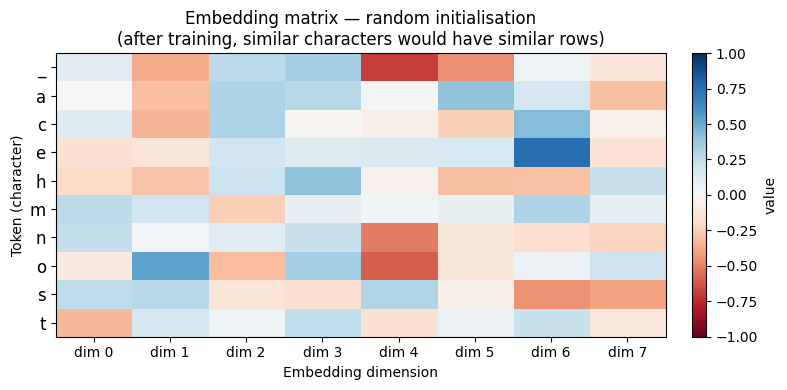


Matrix shape: (10, 8)  → 10 tokens × 8 dimensions
At random init the pattern is noise — this is expected.


In [5]:
import matplotlib.pyplot as plt

# Labels for the y-axis: the character each row represents.
char_labels = sorted(tok.stoi.keys())
# Display spaces as '_' so they're visible on the plot.
display_labels = [('_' if ch == ' ' else ch) for ch in char_labels]

fig, ax = plt.subplots(figsize=(8, 4))

# imshow treats rows as y and columns as x, which is what we want:
# y-axis = token (character), x-axis = embedding dimension.
im = ax.imshow(E, cmap="RdBu", aspect="auto", vmin=-1, vmax=1)

ax.set_yticks(range(len(display_labels)))
ax.set_yticklabels(display_labels, fontsize=12)
ax.set_xticks(range(D_MODEL))
ax.set_xticklabels([f"dim {i}" for i in range(D_MODEL)])
ax.set_xlabel("Embedding dimension")
ax.set_ylabel("Token (character)")
ax.set_title("Embedding matrix — random initialisation\n(after training, similar characters would have similar rows)")

fig.colorbar(im, ax=ax, fraction=0.03, pad=0.04, label="value")
plt.tight_layout()
plt.show()

print(f"\nMatrix shape: {E.shape}  → {tok.vocab_size} tokens × {D_MODEL} dimensions")
print("At random init the pattern is noise — this is expected.")

## Summary

| Concept | Shape | What it is |
|---|---|---|
| Embedding matrix `E` | `(vocab_size, d_model)` | One learned vector per token type |
| Sequence embedding `X` | `(seq_len, d_model)` | One vector per token *position*, looked up from `E` |

**From this point on, the entire transformer operates on `X`** — a `(seq_len, d_model)` matrix of vectors. We will transform it many times through attention and feed-forward layers, but we never go back to integers until the very end.

**Mental picture:** imagine a cloud of 22 points in 8-dimensional space — one per character in "the cat sat on the mat". Each point is just a random location right now. The next section (Section 4: Attention) is about measuring *how similar* pairs of points are to each other — the first step toward letting tokens influence each other's representations.